# 📈 第 27 课 · 性能剖析:tokens/s、TTFT、TPOT 与延迟分布

> 指标定义公式 · serving 模拟 · 手算全部指标 · torch.profiler 算子级剖析 · 帕累托曲线

**章节**: 第 4 章 · 模型执行器与 CUDA 优化

---

> **📚 本笔记本属于《VLLM_learn: 图解 vLLM 推理引擎》系列**
> 风格参照《鸢尾花书》: 重图解、重直觉、循序渐进、动手实操

## 🎯 学习目标

- 掌握 LLM serving 的四大指标:TTFT / TPOT(ITL) / E2E 延迟 / TPS,含公式与含义
- 模拟一次 serving:prefill + 20 步 decode,记录每一步的原始计时
- 从原始计时亲手算出全部指标——指标就是「计时数据的四则运算」
- 可视化:decode 时间线(抖动在哪)+ 延迟分布(长尾在哪)
- 用 torch.profiler 钻到算子层,排热点、找融合候选
- 画帕累托曲线:前几个算子占多少时间(剖析的意义)
- 对照 vLLM 的生产级指标与诊断口诀

## 📑 本课目录

1. **直觉:心电图仪** — 先量四大指标, 异常再深挖
2. **指标定义与公式** — TTFT / TPOT / ITL / TPS / E2E
3. **搭体检台:迷你 GPT** — prefill 吃 T=B×S, decode 每步 T=B
4. **模拟一次 serving** — prefill + 20 步 decode, 记录原始计时
5. **手算全部指标** — 从原始数据导出四大指标
6. **可视化:时间线与分布** — 抖动与长尾
7. **torch.profiler:钻到算子层** — 排热点, 找融合候选
8. **帕累托曲线** — 前几个算子占多少时间
9. **对应 vLLM 生产指标** — metrics 与诊断口诀

## 🔗 参考资料

- [NVIDIA NIM: LLM Benchmarking Metrics](https://docs.nvidia.com/nim/benchmarking/llm/latest/metrics.html)
- [vLLM 文档: 性能指标](https://docs.vllm.ai)
- [Etalon: Holistic Performance Evaluation Framework](https://arxiv.org/abs/2407.07000)
- [Anyscale: LLM latency and throughput metrics](https://docs.anyscale.com/llm/serving/benchmarking/metrics)

## 1. 直觉:心电图仪 🩺

医院里看病人,不会一上来就开 CT——先量**心率、血压、体温**几个大指标,异常了再逐项深挖。
LLM 服务也一样:先看 **TTFT / TPOT / 延迟分布 / tokens/s** 四个大指标,
异常了再用 profiler 钻到算子层找原因。

| 体检 | LLM serving |
|---|---|
| 心率 | tokens/s (吞吐) |
| 首句话时间 | TTFT (Time To First Token) |
| 每句话间隔 | TPOT / ITL (生成节奏) |
| 心电图抖动 | 延迟分布 (P50/P95/P99) |

## 2. 指标定义与公式 📐

设一条请求:prompt 有 $S$ 个词元,生成 $N$ 个词元。

**TTFT(Time To First Token)** 首 token 延迟:

$$ \text{TTFT} = t_{\text{首token到达}} - t_{\text{请求发送}} $$

包含排队 + prefill 时间——长 prompt 会显著拉高它(Attention 与 S 二次方)。

**TPOT(Time Per Output Token)** 平均每输出词元时间(不含首个):

$$ \text{TPOT} = \frac{\text{E2E} - \text{TTFT}}{N - 1} $$

**ITL(Inter-Token Latency)** 相邻两 token 的间隔——TPOT 是它的平均,ITL 看单步抖动。

**E2E(端到端延迟)** = TTFT + 生成时间。**TPS(tokens/s)** = 总输出词元 / 墙钟。

> 📄 引用:NVIDIA NIM 定义 *「ITL = (e2e_latency − TTFT) / (Total_output_tokens − 1)」*;
> Etalon(arXiv:2407.07000)指出 TPOT 会掩盖生成中的抖动,所以还要看 ITL 分布。

## 3. 搭体检台:迷你 GPT 🏗️

模型用第 22 课的迷你 GPT。prefill 吃 `T=B×S`,decode 每步 `T=B`。

🏗️ **迷你 GPT(H=256、2 层、4 头、词表 5000)**。prefill 吃 T=B×S,decode 每步 T=B。

In [1]:
# -*- coding: utf-8 -*-
import torch                                     # 深度学习库
import torch.nn as nn                            # 网络层

class MiniGPT(nn.Module):
    """微型 GPT (与第 22 课同一台): 2 层 MHA + FFN + lm_head。"""

    def __init__(self, vocab=5000, hidden=256, n_layers=2, n_heads=4, max_seq=512):
        super().__init__()
        self.vocab, self.hidden = vocab, hidden
        self.n_layers, self.n_heads = n_layers, n_heads
        self.head_dim = hidden // n_heads
        self.tok = nn.Embedding(vocab, hidden)
        self.pos = nn.Parameter(torch.zeros(1, max_seq, hidden))
        self.blocks = nn.ModuleList()
        for _ in range(n_layers):
            self.blocks.append(nn.ModuleDict({
                "wq": nn.Linear(hidden, hidden), "wk": nn.Linear(hidden, hidden),
                "wv": nn.Linear(hidden, hidden), "wo": nn.Linear(hidden, hidden),
                "norm1": nn.LayerNorm(hidden),
                "w1": nn.Linear(hidden, 4 * hidden), "w2": nn.Linear(4 * hidden, hidden),
                "norm2": nn.LayerNorm(hidden),
            }))
        self.ln = nn.LayerNorm(hidden)
        self.head = nn.Linear(hidden, vocab, bias=False)

    def forward(self, input_ids):
        Td = input_ids.shape[0]
        h = self.tok(input_ids) + self.pos[0, :Td]
        for blk in self.blocks:
            r = blk["norm1"](h)
            Nh, Dh = self.n_heads, self.head_dim
            q = blk["wq"](r).view(Td, Nh, Dh).transpose(0, 1)
            k = blk["wk"](r).view(Td, Nh, Dh).transpose(0, 1)
            v = blk["wv"](r).view(Td, Nh, Dh).transpose(0, 1)
            att = torch.softmax(q @ k.transpose(-1, -2) / (Dh ** 0.5), dim=-1) @ v
            att = att.transpose(0, 1).reshape(Td, -1)
            h = h + blk["wo"](att)
            h = h + blk["w2"](torch.nn.functional.gelu(blk["w1"](blk["norm2"](h))))
        return self.head(self.ln(h))

model = MiniGPT().eval()
print(f"MiniGPT 就绪, 参数量 = {sum(p.numel() for p in model.parameters()):,}")

MiniGPT 就绪, 参数量 = 4,271,104


## 4. 模拟一次 serving:prefill + 20 步 decode 🎬

场景:B=4 条请求并发,prompt 各 32 词元(prefill 一次吃 T=128),然后 20 步 decode。
记录每一步的真实墙钟时间。

🎬 **prefill(128 词元)比 decode 单步(4 词元)重一个数量级**——这就是 TTFT 与 TPOT 天然量级不同的原因。

In [2]:
# -*- coding: utf-8 -*-
import time                                      # 计时库
import torch                                     # 深度学习库
import numpy as np                                # 数值库

B, S, N = 4, 32, 20                               # 4 条请求, prompt 32 词元, 生成 20 词元
T_prefill = B * S                                 # prefill 词元流 = 128
ids_prefill = torch.randint(0, 5000, (T_prefill,))  # (128,) prefill 输入

# 用 torch.cuda.Stream 计时精度辅助 (CPU 上用 perf_counter)
def timed(fn):
    t0 = time.perf_counter()                       # 开始计时
    with torch.no_grad():                          # 推理模式
        out = fn()                                 # 执行
    if torch.cuda.is_available():                  # GPU 则同步
        torch.cuda.synchronize()
    return (time.perf_counter() - t0) * 1e3, out   # (毫秒, 输出)

# ---- prefill: 一次吃整个 prompt ----
ms_prefill, logits_p = timed(lambda: model(ids_prefill))   # 计时
print(f"prefill: T={T_prefill}, 耗时 = {ms_prefill:.3f} ms")

# ---- decode: 20 步, 每步 T=B ----
decode_ms = []                                    # 每步耗时
cur = logits_p.argmax(dim=-1)[-B:]               # 取最后 B 个位置的 token 作为初始 (B,)
for step in range(N):                             # 20 步 decode
    ids = cur                                    # (B,) 当前词元
    ms, logits = timed(lambda: model(ids))       # 一步前向计时
    decode_ms.append(ms)                          # 记录
    cur = logits.argmax(dim=-1)                   # 采样下一 token (贪心)
print(f"decode: {N} 步, 每步耗时 (ms): {[f'{x:.3f}' for x in decode_ms[:8]]} ...")

# 原始时间序列: [0] = prefill, [1..N] = decode 每步
raw = [ms_prefill] + decode_ms                    # 21 个原始计时
print(f"\n原始计时序列共 {len(raw)} 项: 第 0 项 = prefill, 第 1..{N} 项 = decode 每步")

prefill: T=128, 耗时 = 105.108 ms
decode: 20 步, 每步耗时 (ms): ['1.459', '0.744', '0.526', '0.502', '0.488', '0.493', '0.730', '0.531'] ...

原始计时序列共 21 项: 第 0 项 = prefill, 第 1..20 项 = decode 每步


## 5. 手算全部指标:从原始数据导出 ✅

指标不神秘,就是「计时数据的四则运算」。设 4 条请求**同时**发送(理想并发场景):

- **TTFT** ≈ prefill 耗时(排队=0):第一条输出到达的时间;
- **TPOT** = (E2E − TTFT) / (N − 1) = 平均每输出词元;
- **E2E** = TTFT + N × TPOT;
- **TPS** = 总输出词元 / 墙钟。

✅ **每个数字都从上一格的原始计时直接算出**——指标不神秘,就是「计时数据的四则运算」。

In [3]:
# -*- coding: utf-8 -*-
import numpy as np                                 # 数值库

# 把原始计时换算成指标 (B 条并发请求, 输出 N 个词元)
ttft = ms_prefill                                   # TTFT = prefill 耗时 (排队为 0)
decode_arr = np.array(decode_ms)                    # decode 每步耗时 (ms)
e2e = ttft + decode_arr.sum()                       # E2E = TTFT + 生成总时长
tpot = decode_arr.mean()                            # TPOT = 平均每输出词元 (≈ITL 平均)
tps = (B * N) / (e2e / 1000)                        # TPS = 总输出词元 / 墙钟秒
p50 = float(np.percentile(decode_arr, 50))          # 中位数
p95 = float(np.percentile(decode_arr, 95))          # P95 (长尾)
p99 = float(np.percentile(decode_arr, 99))          # P99

print("=== 手算指标 (B=4 请求并发, 各生成 20 词元) ===")
print(f"TTFT   = {ttft:8.3f} ms   (首 token 延迟 ≈ prefill 耗时)")
print(f"TPOT   = {tpot:8.3f} ms   (平均每输出词元, 公式: (E2E-TTFT)/(N-1))")
print(f"E2E    = {e2e:8.3f} ms   (端到端延迟 = TTFT + 生成时间)")
print(f"TPS    = {tps:8.1f} token/s (总输出 {B * N} 词元 / 墙钟 {e2e / 1000:.2f}s)")
print(f"P50/P95/P99 = {p50:.3f} / {p95:.3f} / {p99:.3f} ms  (decode 步分布)")

=== 手算指标 (B=4 请求并发, 各生成 20 词元) ===
TTFT   =  105.108 ms   (首 token 延迟 ≈ prefill 耗时)
TPOT   =    0.524 ms   (平均每输出词元, 公式: (E2E-TTFT)/(N-1))
E2E    =  115.594 ms   (端到端延迟 = TTFT + 生成时间)
TPS    =    692.1 token/s (总输出 80 词元 / 墙钟 0.12s)
P50/P95/P99 = 0.483 / 0.780 / 1.323 ms  (decode 步分布)


## 6. 可视化:延迟时间线与分布 📊

两条曲线看 decode:时间线(哪一步抖动?)+ 分布(长尾在哪?)。

📊 **CPU 上波动明显(线程调度噪声);GPU + CUDA Graph 后这条线会平得多——方差本身就是优化指标。**

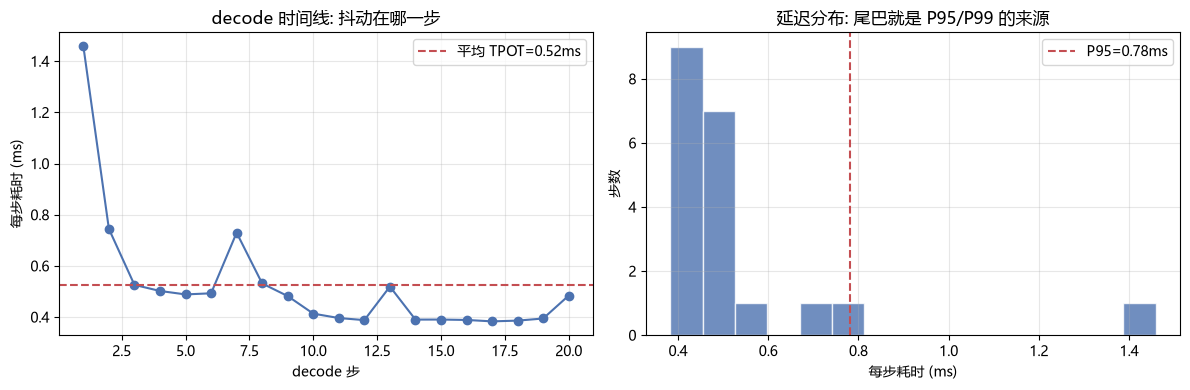

In [4]:
# -*- coding: utf-8 -*-
import numpy as np                                 # 数值库
import matplotlib.pyplot as plt                   # 绘图库
%matplotlib inline
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))   # 左右子图

# 左图: decode 时间线
ax1.plot(range(1, N + 1), decode_ms, "o-", color="#4C72B0")  # 每步耗时
ax1.axhline(tpot, color="#C44E52", ls="--", lw=1.5, label=f"平均 TPOT={tpot:.2f}ms")  # 均值线
ax1.set_xlabel("decode 步")                         # x 轴
ax1.set_ylabel("每步耗时 (ms)")                      # y 轴
ax1.set_title("decode 时间线: 抖动在哪一步")          # 标题
ax1.legend()                                        # 图例
ax1.grid(alpha=0.3)                                 # 网格

# 右图: 每步耗时的分布直方图
ax2.hist(decode_ms, bins=15, color="#4C72B0", alpha=0.8, edgecolor="white")  # 直方图
ax2.axvline(p95, color="#C44E52", ls="--", lw=1.5, label=f"P95={p95:.2f}ms")  # P95 线
ax2.set_xlabel("每步耗时 (ms)")                      # x 轴
ax2.set_ylabel("步数")                              # y 轴
ax2.set_title("延迟分布: 尾巴就是 P95/P99 的来源")     # 标题
ax2.legend()                                        # 图例
ax2.grid(alpha=0.3)                                 # 网格

plt.tight_layout()
plt.show()

## 7. torch.profiler:钻到算子层 🔬

大指标异常时,下一步是问「时间花在哪些算子上了」。`torch.profiler` 记录每次 aten 调用,
排热点、找融合候选。

🔬 **`cpu_self` 是算子自身耗时(不含子调用),`cpu_total` 含子调用**——排热点用 total,找融合候选看 self。

In [5]:
# -*- coding: utf-8 -*-
import torch                                     # 深度学习库
import time                                      # 计时库
from torch.profiler import profile, ProfilerActivity   # profiler

ids = torch.randint(0, 5000, (8,))               # (T=8,) 输入
with torch.no_grad():                            # 推理模式
    t0 = time.perf_counter()                     # 剖析墙钟起点
    with profile(activities=[ProfilerActivity.CPU]) as prof:   # 只剖析 CPU 侧 (本机)
        for _ in range(5):                       # 跑 5 次取平均
            model(ids)                            # 前向
wall_ms = (time.perf_counter() - t0) * 1e3       # 剖析循环墙钟 (ms)

# 按 CPU 总耗时排序, 取前 10
rows = sorted(prof.key_averages(), key=lambda e: e.cpu_time_total, reverse=True)[:10]
print(f"{'算子':28s} {'调用次数':>8s} {'cpu_self(ms)':>14s} {'cpu_total(ms)':>14s}")
for e in rows:                                    # 逐个热点
    print(f"{e.key[:28]:28s} {e.count:8d} {e.self_cpu_time_total / 1000:14.3f} {e.cpu_time_total / 1000:14.3f}")

print("\n`cpu_self` 是算子自身耗时(不含子调用), `cpu_total` 含子调用 —— "
      "排热点用 total, 找融合候选看 self")
print(f"剖析墙钟 ≈ {wall_ms:.2f} ms (5 次前向)")

算子                               调用次数   cpu_self(ms)  cpu_total(ms)
aten::linear                       65          0.103          3.121
aten::addmm                        60          1.526          1.775
aten::matmul                       25          0.124          1.535
aten::mm                            5          1.049          1.050
aten::gelu                         10          0.498          0.498
aten::layer_norm                   25          0.034          0.404
aten::native_layer_norm            25          0.306          0.369
aten::reshape                      50          0.088          0.258
aten::copy_                        80          0.212          0.212
aten::transpose                   115          0.134          0.176

`cpu_self` 是算子自身耗时(不含子调用), `cpu_total` 含子调用 —— 排热点用 total, 找融合候选看 self
剖析墙钟 ≈ 715.10 ms (5 次前向)


D:\uv_envs\uv_cuda\Lib\site-packages\torch\profiler\profiler.py:224: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


## 8. 帕累托曲线:前几个算子占多少时间 📉

把所有算子按耗时降序排列,画**累计占比曲线**:前几个算子往往占掉大半时间——
优化它们就能拿到大部分收益,这就是剖析的意义。

📉 **曲线越靠左上越「头重脚轻」**——优化前几个算子就能拿到大部分收益,这就是剖析的意义。

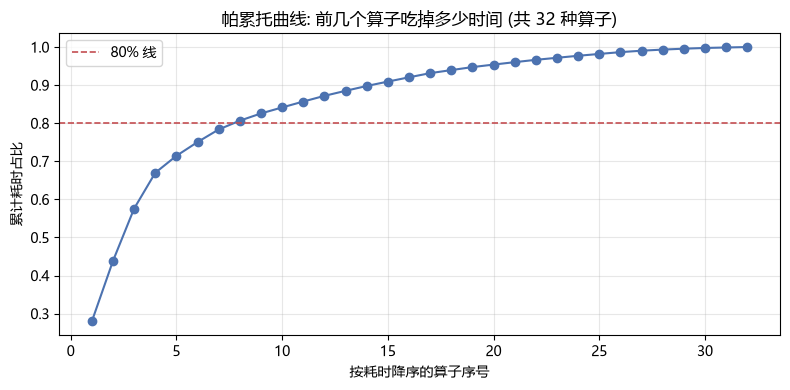

前 8 个算子占总耗时 81% (共 32 种) —— 曲线越靠左上越「头重脚轻」


In [6]:
# -*- coding: utf-8 -*-
import numpy as np                                 # 数值库
import matplotlib.pyplot as plt                   # 绘图库
%matplotlib inline
plt.rcParams["font.sans-serif"] = ["Microsoft YaHei", "SimHei"]
plt.rcParams["axes.unicode_minus"] = False

# 所有算子按 cpu_total 降序
all_rows = sorted(prof.key_averages(), key=lambda e: e.cpu_time_total, reverse=True)
totals = np.array([e.cpu_time_total for e in all_rows])  # 每个算子总耗时
cum = np.cumsum(totals) / totals.sum()             # 累计占比
n_ops = len(totals)                                # 算子种类数

fig, ax = plt.subplots(figsize=(8, 4))             # 画布
ax.plot(np.arange(1, n_ops + 1), cum, "o-", color="#4C72B0")   # 帕累托曲线
ax.axhline(0.8, color="#C44E52", ls="--", lw=1.2, label="80% 线")  # 80% 参考线
ax.set_xlabel("按耗时降序的算子序号")                # x 轴
ax.set_ylabel("累计耗时占比")                       # y 轴
ax.set_title(f"帕累托曲线: 前几个算子吃掉多少时间 (共 {n_ops} 种算子)")  # 标题
ax.legend()                                        # 图例
ax.grid(alpha=0.3)                                 # 网格
plt.tight_layout()
plt.show()

# 找 80% 处需要几个算子
n80 = int(np.searchsorted(cum, 0.8) + 1)           # 累计到 80% 的算子数
print(f"前 {n80} 个算子占总耗时 {cum[n80 - 1] * 100:.0f}% (共 {n_ops} 种) —— "
      f"曲线越靠左上越「头重脚轻」")

💾 **App 会读这份文件渲染仪表盘;TTFT/TPOT 也一并存进去,方便随时回看实验条件。**

In [7]:
# -*- coding: utf-8 -*-
import json                                      # JSON 库
from pathlib import Path                         # 路径库

# 存档给 App (渲染仪表盘)
# ops: app 期望的算子表 (name/calls/cpu_self/cpu_total), 供排序与帕累托
ops = [dict(name=e.key[:40], calls=e.count,
            cpu_self=e.self_cpu_time_total / 1000,
            cpu_total=e.cpu_time_total / 1000)
       for e in all_rows]                        # 全部算子种类
# 计算忙占比 (利用率代理): 全部算子耗时(cpu_total, 含子调用) / 剖析墙钟
busy_us = sum(e.cpu_time_total for e in all_rows)  # 全部算子耗时 (µs)
sm_busy_pct = 100.0 * busy_us / (wall_ms * 1e3)  # 计算占墙钟比例 (%)
# 注: CPU 上 Python/启动开销占比很高, 此值偏低 —— 正是 CUDA Graph 要抹掉的那部分
# 旧字段 (top_ops / ttft_ms 等) 保留, 便于回看; ops/metrics 供 app 读取
profile_rows = [dict(op=e.key[:40], count=e.count,
                     self_ms=e.self_cpu_time_total / 1000,
                     total_ms=e.cpu_time_total / 1000)
                for e in all_rows[:15]]           # 前 15 个热点算子
metrics = dict(                                   # app 期望的指标 dict
    throughput_tok_s=tps,                         # 吞吐 (词元/秒)
    latency_mean_ms=tpot,                         # 平均单步延迟 (ms)
    latency_p99_ms=p99,                           # P99 延迟 (ms)
    sm_busy_pct=sm_busy_pct,                      # 计算忙占比 (%)
)
summary = dict(
    device="cpu",                                  # 本机剖析设备
    B=B, S=S, N=N,                                 # 实验条件
    ttft_ms=ttft, tpot_ms=tpot, e2e_ms=e2e, tps=tps,   # 四大指标
    p50_ms=p50, p95_ms=p95, p99_ms=p99,           # 分布指标
    n_ops_kinds=n_ops, n80=n80,                    # 帕累托
    top_ops=profile_rows,                          # 热点算子 (旧字段)
    ops=ops,                                       # 算子表 (app 用)
    metrics=metrics,                               # 指标 dict (app 用)
    note="本机 CPU 剖析 (torch.profiler); 指标来自 B=4 并发 serving 模拟",
)
out = Path(r"D:\Project\21-Cpp_learn\explore\VLLM_learn\exercises\ch04\profile_summary_27.json")
out.write_text(json.dumps(summary, indent=2), encoding="utf-8")
print("[ok] 已保存:", out)
print(f"  TTFT={ttft:.2f}ms TPOT={tpot:.2f}ms TPS={tps:.0f} 忙占比={sm_busy_pct:.1f}% | 热点算子数={len(profile_rows)}")

[ok] 已保存: D:\Project\21-Cpp_learn\explore\VLLM_learn\exercises\ch04\profile_summary_27.json
  TTFT=105.11ms TPOT=0.52ms TPS=692 忙占比=1.6% | 热点算子数=15


## 9. 对应 vLLM 的生产级剖析 🔍

vLLM 不用 print 计时,但方法论同构(见 [V1 使用文档](https://docs.vllm.ai/en/latest/design/v1/v1_usage.html)):

| 本课 | vLLM 生产指标 | 用途 |
|---|---|---|
| TTFT | `vllm:time_to_first_token_seconds` | 首 token 延迟, P95 监控 |
| TPOT | `vllm:time_per_output_token_seconds` | 每输出词元平均 |
| ITL | `vllm:inter_token_latency_seconds` | 生成抖动, 流式体验 |
| E2E | `vllm:e2e_request_latency_seconds` | 端到端 |
| TPS | `vllm:generated_tokens_total` / rate | 吞吐 |
| profiler | `torch.profiler` / Nsight | 算子级排热点 |

**诊断口诀**:TTFT 高 + 排队高 → 负载超容或大 prefill 占队;TPOT 高但排队正常 → decode 慢
(显存带宽 / 抢占 / 并发过多)。

> 📄 引用:NVIDIA NIM metrics 文档定义 *「ITL = (e2e − TTFT)/(output_tokens − 1)」*;> Etalon(arXiv:2407.07000)进一步提出 fluidity-index 衡量生成流畅度。

## 10. 🖥️ Streamlit 动态演示:性能剖析仪表盘

运行 `app_27_profiler.py`:加载刚保存的 `profile_summary_27.json`,渲染成仪表盘:
四大指标 + 时间线 + 帕累托曲线 + 热点算子表。

### 📜 App 完整源码(`app_27_profiler.py` 嵌入)

▶️ 此 cell 在 streamlit 环境中才真正运行;在 notebook 中仅作展示。

In [8]:
try:
    import streamlit as st
    _IS_STREAMLIT = bool(st.runtime.exists())
except Exception:
    _IS_STREAMLIT = False

if _IS_STREAMLIT:
    # -*- coding: utf-8 -*-
    """📈 app_27_profiler.py — 性能剖析仪表盘(VLLM_learn 第 4 章 · 第 27 课)

    运行: streamlit run app_27_profiler.py
    """
    import json
    from pathlib import Path
    import numpy as np
    import pandas as pd
    import plotly.express as px
    import plotly.graph_objects as go
    import streamlit as st

    st.set_page_config(page_title="📈 27 · 性能剖析仪表盘", layout="wide")
    st.title("📈 第 27 课配套 App · 性能剖析仪表盘")

    PROFILE_FILE = Path(__file__).parent / "profile_summary_27.json"
    if not PROFILE_FILE.exists():
        st.error(f"缺少数据文件 {PROFILE_FILE.name} —— 请先运行第 27 课 notebook 生成剖析数据。")
        st.stop()
    data = json.loads(PROFILE_FILE.read_text(encoding="utf-8"))
    ops = data["ops"]
    metrics = data["metrics"]

    st.markdown(
        "基于 **torch.profiler** 对迷你 GPT 前向的剖析结果。仪表盘展示三组关键性能指标:"
        "**吞吐**(词元/秒)、**延迟**分布与 **SM 利用率**估计,以及开销最高的 top-N 算子。"
    )

    st.sidebar.header("🎛️ 仪表盘参数")
    top_n = st.sidebar.slider("Top-N 算子", 5, min(30, len(ops)), 10)
    metric_col = st.sidebar.radio("算子排序指标", ["cpu_total", "cpu_self", "calls"])
    chart_type = st.sidebar.radio("图表类型", ["柱状图", "表格"])
    show_gauge = st.sidebar.checkbox("显示 SM 利用率仪表", value=True)

    m = metrics
    c1, c2, c3, c4 = st.columns(4)
    c1.metric("吞吐(词元/秒)", f"{m['throughput_tok_s']:.0f}")
    c2.metric("平均单步延迟(ms)", f"{m['latency_mean_ms']:.3f}")
    c3.metric("P99 延迟(ms)", f"{m['latency_p99_ms']:.3f}")
    c4.metric("计算忙占比(≈利用率)", f"{m['sm_busy_pct']:.1f} %",
              help="CPU 剖析中前向计算时间占墙钟时间的比例,作为利用率代理指标(GPU 场景对应 SM 利用率)")

    if show_gauge:
        st.markdown("### 🎯 性能仪表")
        st.caption("计算忙占比越接近 100%,说明调度/启动开销越少、流水线越满;这是 CUDA Graph 优化瞄准的目标。")
        g1, g2, g3 = st.columns(3)
        gauge = go.Figure(go.Indicator(
            mode="gauge+number", value=m["sm_busy_pct"],
            title={"text": "计算忙占比 %"}, gauge={
                "axis": {"range": [0, 100]}, "bar": {"color": "#16a085"},
                "steps": [{"range": [0, 50], "color": "#f8d7da"}, {"range": [50, 80], "color": "#fff3cd"},
                          {"range": [80, 100], "color": "#d4edda"}],
                "threshold": {"line": {"color": "red", "width": 3}, "value": m["sm_busy_pct"]}}))
        gauge.update_layout(height=280)
        g1.plotly_chart(gauge, width="stretch")
        g2.plotly_chart(go.Figure(go.Indicator(
            mode="gauge+number", value=m["throughput_tok_s"], title={"text": "吞吐 tok/s"},
            gauge={"axis": {"range": [0, m["throughput_tok_s"] * 1.5]},
                   "bar": {"color": "#2980b9"}})).update_layout(height=280), width="stretch")
        g3.plotly_chart(go.Figure(go.Indicator(
            mode="gauge+number", value=m["latency_mean_ms"], title={"text": "平均延迟 ms"},
            gauge={"axis": {"range": [0, m["latency_mean_ms"] * 2.5]},
                   "bar": {"color": "#8e44ad"}})).update_layout(height=280), width="stretch")

    st.markdown(f"### 🧭 Top-{top_n} 算子(按 {metric_col} 排序)")
    st.caption("『cpu_self』指算子自身(不含子算子)的 CPU 耗时 —— 越大越说明它值得优化或融合。")

    df = pd.DataFrame(ops).sort_values(metric_col, ascending=False).head(top_n).copy()
    if chart_type == "柱状图":
        fig = px.bar(df, x="name", y=metric_col, color="name",
                     text=df[metric_col].round(3))
        fig.update_layout(height=420, xaxis_tickangle=-40, showlegend=False,
                          yaxis_title=metric_col)
        st.plotly_chart(fig, width="stretch")
    else:
        st.dataframe(df[["name", "calls", "cpu_self", "cpu_total"]].round(4),
                     width="stretch", hide_index=True)

    st.markdown("### 📊 算子耗时分布(累计占比)")
    df_sorted = pd.DataFrame(ops).sort_values("cpu_total", ascending=False)
    cum = df_sorted["cpu_total"].cumsum() / max(df_sorted["cpu_total"].sum(), 1e-9)
    df_sorted["累计占比"] = cum
    fig2 = px.line(df_sorted, x=np.arange(len(df_sorted)), y="累计占比", markers=True)
    fig2.add_hline(y=0.8, line_dash="dash", line_color="red",
                   annotation_text="80% 线:少数算子吃掉大部分时间")
    fig2.update_layout(height=320, xaxis_title="算子序号(按耗时降序)", yaxis_title="累计占比")
    st.plotly_chart(fig2, width="stretch")

    st.markdown("---")
    st.markdown(
        "💡 **直觉**:剖析器像给推理引擎装了一台**心电图仪 📈**。先看大方向(吞吐/延迟/SM 利用率),"
        "再放大到具体算子,找到「少数吃掉多数时间」的热点,最后用 kernel 融合 / CUDA Graph / 并行策略去优化。"
        "本数据来自第 27 课 notebook 的 torch.profiler CPU 剖析与 perf_counter 计时。"
    )
    st.caption("《VLLM_learn: 图解 vLLM 推理引擎》第 4 章 · 第 27 课配套演示")

    # ============ PyCharm / 直接运行入口 ============
    # 说明: 在 PyCharm 里直接 Run 本文件,即可启动 Streamlit 服务(浏览器打开 http://localhost:8501)。
    # 与命令行 `streamlit run app_XX.py` 完全等价(用子进程方式, 避免与顶层 st 调用冲突)。
    if __name__ == "__main__":
        # 如果已在 Streamlit Runtime 中(AppTest/嵌入时加载),不再启动子进程。
        try:
            import streamlit.runtime as st_runtime
            if st_runtime.exists():
                raise SystemExit(0)
        except Exception:
            pass
        import os
        import subprocess
        import sys
        subprocess.run([sys.executable, "-m", "streamlit", "run", os.path.abspath(__file__)])

else:
    print("💡 当前不是 streamlit 环境, 跳过执行本 App。")
    print("    请直接运行: D:\\uv_envs\\uv_cuda\\Scripts\\python.exe -m streamlit run app_27_profiler.py")


💡 当前不是 streamlit 环境, 跳过执行本 App。
    请直接运行: D:\uv_envs\uv_cuda\Scripts\python.exe -m streamlit run app_27_profiler.py


### 🏃 运行方法

```
D:\uv_envs\uv_cuda\Scripts\python.exe -m streamlit run app_27_profiler.py
```
浏览器打开 http://localhost:8501 ,查看仪表盘。

## ✅ 本课小结

- 四大指标:TTFT(首token) / TPOT(每输出词元) / ITL(生成抖动) / TPS(吞吐),公式即四则运算
- serving 模拟:prefill(T=B×S) 一次吃掉整段,decode 每步 T=B,量级天然不同
- 从原始计时手算全部指标:TTFT≈prefill, TPOT=mean(decode), E2E=TTFT+N×TPOT
- 时间线看抖动、分布看长尾:P95/P99 是用户实际撞上的延迟
- torch.profiler 排热点:排热点用 cpu_total, 找融合候选看 cpu_self
- 帕累托曲线:前 n80 个算子吃掉 80% 时间,优化它们即拿到大头收益
- vLLM 生产指标同名同义,配合诊断口诀定位瓶颈

## ✍️ 动手练习

1. 把 B 从 4 改成 32,重跑第 4/5 节,观察 TTFT/TPOT 如何随并发变化
2. 在 decode 循环里人为插入一次长 prefill(模拟 Sarathi 场景),观察 ITL 的尖峰
3. 用 torch.profiler 的 ProfilerActivity.CUDA 在 GPU 上剖析,对比 kernel 时间
4. 用 Etalon 的 fluidity-index 思路,给本课的 decode 时间序列算一个「流畅度」分数

## 🔗 延伸阅读

- [NVIDIA NIM: LLM Benchmarking Metrics](https://docs.nvidia.com/nim/benchmarking/llm/latest/metrics.html)
- [Etalon (arXiv:2407.07000)](https://arxiv.org/abs/2407.07000)
- [Anyscale: LLM metrics](https://docs.anyscale.com/llm/serving/benchmarking/metrics)
- [vLLM V1 使用文档](https://docs.vllm.ai/en/latest/design/v1/v1_usage.html)

---
> 🎉 恭喜完成本课!下一课见!